選択されたファイル: E:/001_2026AI班/futabaデータ/黒色PP(J707EG＋cb0.001wt%)/データフォルダ/1.0mm/210℃/050_210℃_120_1.0mm.csv


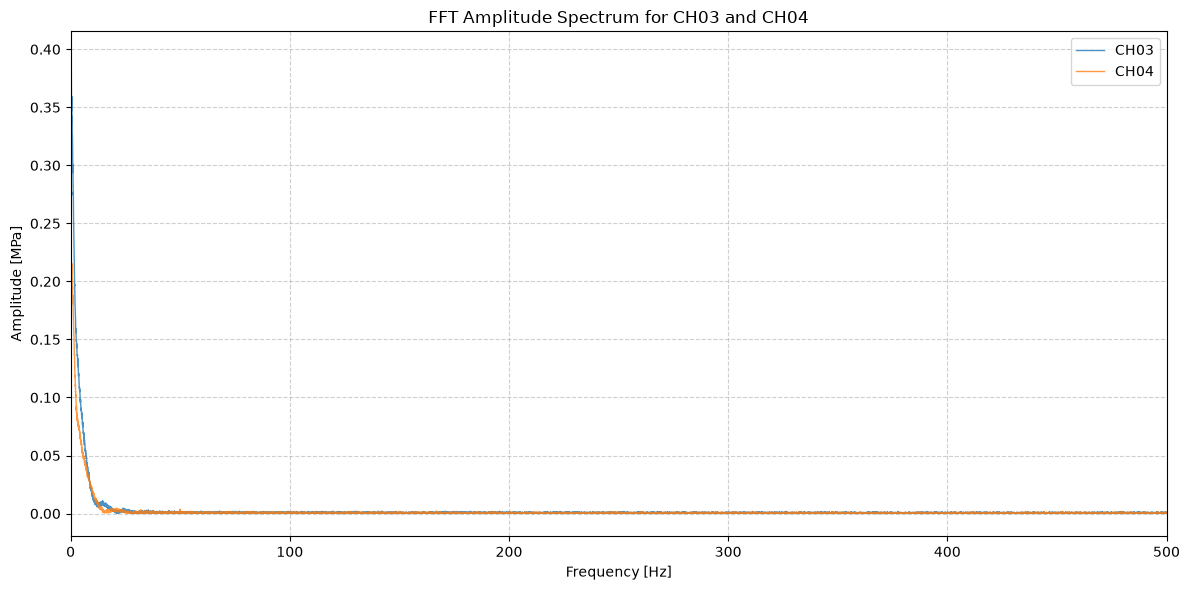

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import sys

# ==========================================
# 1. ファイル選択ダイアログの表示
# ==========================================
# tkinterのルートウィンドウを作成し、非表示にする（ダイアログだけを表示するため）
root = tk.Tk()
root.withdraw()

# ダイアログを常に最前面に表示する設定
root.attributes('-topmost', True)

# ファイル選択ダイアログを開く
file_path = filedialog.askopenfilename(
    title="解析するCSVファイルを選択してください",
    filetypes=[("CSVファイル", "*.csv"), ("すべてのファイル", "*.*")]
)

# ファイルが選択されずにキャンセルされた場合はプログラムを終了
if not file_path:
    print("ファイル選択がキャンセルされました。処理を終了します。")
    sys.exit()

print(f"選択されたファイル: {file_path}")

# ==========================================
# 2. データの読み込みと前処理
# ==========================================
# CSVの3行目(index=2)がカラム名になっているため、header=2で読み込み
df = pd.read_csv(file_path, header=2)

# 4行目(index=0のデータ行)は単位（Unit）の行なので削除し、インデックスをリセット
df = df.drop(0).reset_index(drop=True)

# 解析対象の列を数値型に変換
df['CH03'] = pd.to_numeric(df['CH03'])
df['CH04'] = pd.to_numeric(df['CH04'])

# ==========================================
# 3. FFT (高速フーリエ変換) の計算
# ==========================================
dt = 0.001       # サンプリング間隔 (0.001秒 = 1ms)
N = len(df)      # データサンプル数

y3 = df['CH03'].values
y4 = df['CH04'].values

# フーリエ変換を実行
F3 = np.fft.fft(y3)
F4 = np.fft.fft(y4)

# 振幅を計算 (N/2で割って正規化。直流成分のみNで割る)
amp3 = np.abs(F3) / (N / 2)
amp4 = np.abs(F4) / (N / 2)
amp3[0] /= 2
amp4[0] /= 2

# 周波数軸を生成
freq = np.fft.fftfreq(N, d=dt)

# 正の周波数成分（ナイキスト周波数まで）のみを抽出
mask = (freq >= 0)
freq_pos = freq[mask]
amp3_pos = amp3[mask]
amp4_pos = amp4[mask]

# ==========================================
# 4. グラフの描画
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(freq_pos, amp3_pos, label='CH03', alpha=0.8, linewidth=1.0)
plt.plot(freq_pos, amp4_pos, label='CH04', alpha=0.8, linewidth=1.0)

plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [MPa]')
plt.title('FFT Amplitude Spectrum for CH03 and CH04')
plt.xlim(0, 500) # ナイキスト周波数(500Hz)まで表示
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# グラフを画面に表示（表示されたウィンドウを閉じるとプログラムが終了します）
plt.show()